# Game State Features

**Navigation**: [← Previous: Introduction](01_introduction.ipynb) | [Next: DLS & Resource Methods →](03_dls_resources.ipynb)

We encode each ball in the chase as a feature vector for modelling.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'cricsheet_utils.py').exists():
    PROJ_DIR = Path('projects/cricket-win-probability').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from cricsheet_utils import (
    project_data_dir, load_cricsheet_json, match_metadata, balls_to_dataframe,
    build_game_states, cumulative_runs_by_innings, resource_remaining,
    dls_win_probability,
)
DATA_DIR = project_data_dir()
SAMPLE_DIR = DATA_DIR / 'sample_matches'


In [2]:
training = pd.read_csv(DATA_DIR / 'odi_training_sample.csv')
feature_cols = [
    'runs_scored', 'wickets_lost', 'balls_bowled', 'balls_remaining',
    'wickets_remaining', 'runs_required', 'runs_required_per_ball',
    'current_run_rate', 'target', 'overs_completed',
    'phase_powerplay', 'phase_middle', 'phase_death',
]
training[feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
runs_scored,120000.0,132.790708,77.812029,0.000000,66.000000,132.000000,198.000000,322.0
wickets_lost,120000.0,3.146100,2.187440,0.000000,1.000000,3.000000,5.000000,8.0
balls_bowled,120000.0,150.500000,86.602420,1.000000,75.750000,150.500000,225.250000,300.0
balls_remaining,120000.0,149.500000,86.602420,0.000000,74.750000,149.500000,224.250000,299.0
wickets_remaining,120000.0,6.853900,2.187440,2.000000,5.000000,7.000000,9.000000,10.0
runs_required,120000.0,142.649092,78.515024,0.000000,76.000000,142.000000,208.000000,341.0
runs_required_per_ball,120000.0,1.374173,5.067772,0.000000,0.862903,0.954887,1.072917,99.0
current_run_rate,120000.0,5.286491,1.054857,0.000000,4.813187,5.288136,5.740385,30.0
target,120000.0,275.375000,22.463161,220.000000,260.000000,276.000000,290.250000,341.0
overs_completed,120000.0,25.083333,14.433737,0.166667,12.625000,25.083333,37.541667,50.0


## Correlation structure

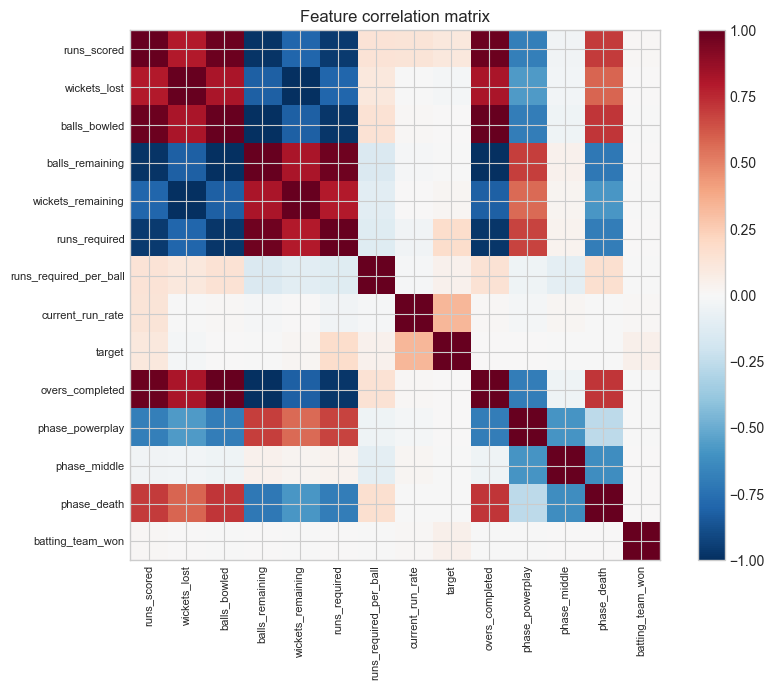

In [3]:
corr = training[feature_cols + ['batting_team_won']].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
plt.colorbar(im, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()


## RRR vs outcome at the final ball

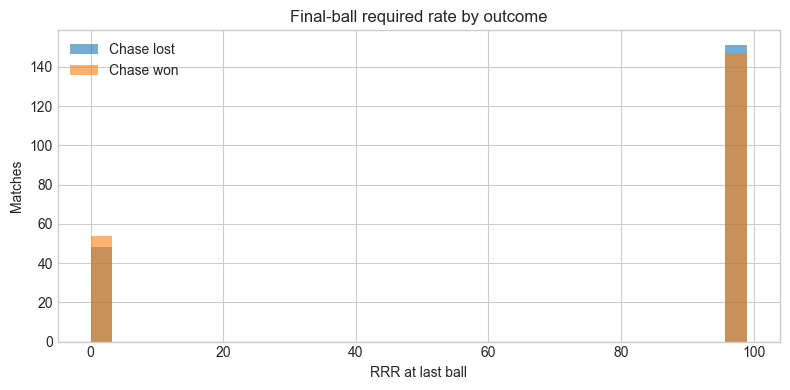

In [4]:
finals = training.groupby('match_idx').tail(1)
fig, ax = plt.subplots(figsize=(8, 4))
for won, grp in finals.groupby('batting_team_won'):
    label = 'Chase won' if won else 'Chase lost'
    ax.hist(grp['runs_required_per_ball'].dropna(), bins=30, alpha=0.6, label=label)
ax.set_xlabel('RRR at last ball')
ax.set_ylabel('Matches')
ax.legend()
ax.set_title('Final-ball required rate by outcome')
plt.tight_layout()
plt.show()


## Example: high-pressure state

In [5]:
pressure = training[(training['over'] >= 43) & (training['wickets_lost'] >= 5)]
pressure.nlargest(1, 'runs_required_per_ball')[feature_cols + ['batting_team_won']]


,runs_scored,wickets_lost,balls_bowled,balls_remaining,wickets_remaining,runs_required,runs_required_per_ball,current_run_rate,target,overs_completed,phase_powerplay,phase_middle,phase_death,batting_team_won
299,228,6,300,0,4,6,99.0,4.56,234,50.0,0,0,1,1


---

**Navigation**: [← Previous: Introduction](01_introduction.ipynb) | [Next: DLS & Resource Methods →](03_dls_resources.ipynb)
